In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm import trange
import ot

### Network Architecture: Fully Connected MLP (Multi Layer Perceptron).
##### This network is designed for the MNIST data set. It takes images of size 28*28 in and then layer 1 has 512 neurons, layer 2 512 neurons, layer 3 512 neurons and then layer 4 10 neurons where a softmax is performed on to produce a probability distribution of output.  
##### _init_ = architecture, forward = computation

In [33]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # self.fc1 = nn.Linear(28*28, 512, bias = False)
        # self.fc2 = nn.Linear(512, 512, bias = False)
        # self.fc3 = nn.Linear(512, 512,bias = False)
        # self.fc4 = nn.Linear(512, 10,bias = False)
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return self.logsoftmax(x)

### Loading Training and Test Data
##### load in the MNIST data set which is preloaded in PyTorch, which transform the data to be suitable to work with tensors (This also involves scaling the original pixel values from 0-255 to be from 0-1 means the activation functions etc are more stable) and download the data. We then divide the data into two subsets A and B which are each half of the training set divided randomly. Load test data set aswell. Think training data is 60,000 images and test is 10,000 images. 

In [34]:
transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
N = len(dataset)
half = N // 2
subsetA, subsetB = random_split(dataset, [half, N - half])
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=512)

### Training the model. 

##### We build a training function for our model. Function defines epochs, learning rate, batch size and verbose.
- Optimisation Algorithm is standard SGD currently, $\theta_{t+1} = \theta_t - \alpha * \nabla L (\theta_t)$
- Loss Function is Negative Log Likelihood Loss. It is the negative of the log probility of the output being in the correct class. If in correct class it will be $-log(1) \approx 0$ and every other class will be negative by negative which is positive, so minimising this loss pushes model to correct classification.
- The network outputs a vector of $10$ log-probabilities, $\ell = \log p = (\ell_0, \ell_1, \ldots, \ell_9)$
- For a given training example with true class label $c$, the loss used is the Negative Log-Likelihood (NLLloss), $L = - \ell_c = - \log p(c)$, which is just the cth entry of the network output. 

Note: The reason we use the log-likelihood loss and not the Cross Entropy loss is because Cross Entropy loss first applies softmax then does log-likelihood loss, which is redundant in our case, as our neural network outputs are already softmaxes.


In [ ]:
def train_model(model, dataset, epochs=10, lr=0.2, batch_size=256, verbose=True):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum = 0, dampening = 0 , weight_decay = 0)
    criterion = nn.NLLLoss()
    model.train()
    for epoch in range(epochs):
        running = 0.0
        for x, y in loader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - loss: {running/len(loader.dataset):.4f}")
    return model

##### Actually training the models

In [36]:
print("Training Model A on subset A...")
modelA = train_model(MLP(), subsetA)
print("Training Model B on subset B...")
modelB = train_model(MLP(), subsetB)
print("Training Full Model on full training dataset")
modelFull = train_model(MLP(), dataset)


stateA = modelA.state_dict()
stateB = modelB.state_dict()
modelFull_state = modelFull.state_dict()


torch.save(modelA.state_dict(), "modelA.pt")
torch.save(modelB.state_dict(), "modelB.pt")
torch.save(modelFull.state_dict(), "modelFull.pt")
print("Saved modelA.pt, modelB.pt, and modelFull.pt")

Training Model A on subset A...
Epoch 1/5 - loss: 1.3075
Epoch 2/5 - loss: 0.3691
Epoch 3/5 - loss: 0.2619
Epoch 4/5 - loss: 0.2002
Epoch 5/5 - loss: 0.1577
Training Model B on subset B...
Epoch 1/5 - loss: 1.2793
Epoch 2/5 - loss: 0.3729
Epoch 3/5 - loss: 0.2651
Epoch 4/5 - loss: 0.2037
Epoch 5/5 - loss: 0.1644
Training Full Model on full training dataset
Epoch 1/5 - loss: 0.8263
Epoch 2/5 - loss: 0.2407
Epoch 3/5 - loss: 0.1626
Epoch 4/5 - loss: 0.1213
Epoch 5/5 - loss: 0.0953
Saved modelA.pt, modelB.pt, and modelFull.pt


##### loading pre-trained model weights

In [37]:
# modelA = MLP()
# modelB= MLP()
# modelFull = MLP()


# modelA.load_state_dict(torch.load("modelA.pt"))
# modelB.load_state_dict(torch.load("modelB.pt"))
# modelFull.load_state_dict(torch.load("modelFull.pt"))


# stateA = modelA.state_dict()
# stateB = modelB.state_dict()
# modelFull_state = modelFull.state_dict()

## Evaluating Models

##### Each trained model is represented by its `state_dict`, which contains all ofthe learned weights and biases. To evaluate a model, we instantiate a fresh `MLP` object, load the saved `state_dict` into it, switch the model to evaluation mode, and compute accuracy on the MNIST test set.

##### Only the weights are required for evaluation—the full training procedure is not needed once the model has been trained.

In [38]:
def evaluate_model_state_dict(state_dict, model_cls=MLP):
    m = model_cls()
    m.load_state_dict(state_dict)
    m.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            out = m(x)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

print("Eval Model A:", evaluate_model_state_dict(stateA))
print("Eval Model B:", evaluate_model_state_dict(stateB))
print("Eval Full Model:", evaluate_model_state_dict(modelFull_state))

Eval Model A: 0.9439
Eval Model B: 0.9247
Eval Full Model: 0.9715


### Baseline Model Merging

We merge Model A and Model B using naive linear interpolation of their 
parameters. For each layer parameter $\theta$, we construct an interpolated
model


$ \theta_{\text{merged}}(\lambda) = (1 - \lambda)\theta_A + \lambda\theta_B, $

sweeping $\lambda$ from 0 to 1. This produces a straight-line path in parameter
space between the two independently trained models. We evaluate the accuracy of
each interpolated model to observe how performance changes along this path. For
independently trained networks, naive interpolation usually exhibits a sharp
drop in accuracy in the middle, reflecting a high-loss barrier between distinct
SGD minima.

In [39]:
def interp_states(state1, state2, lam):
    out = {}
    for k in state1.keys():
        out[k] = (1 - lam) * state1[k].float() + lam * state2[k].float()
    return out

lambdas = np.linspace(0, 1, 21)
merged_naive_acc = []
for lam in lambdas:
    s = interp_states(stateA, stateB, lam)
    merged_naive_acc.append(evaluate_model_state_dict(s))
print("Naive interpolation done.")

Naive interpolation done.


### Linearly Connected Modes  (LMCs)

Two trained models (say **A** and **B**) are said to be *linearly connected* if there exists a simple linear path between their parameters:


$\theta(\lambda) = (1 - \lambda)\,\theta_A + \lambda\,\theta_B,$

such that the **loss stays low** (or accuracy stays high) for all values of \(\lambda \in [0,1]\).

The plot below reviels how poor the naive interpolation (model parameter averaging) works 

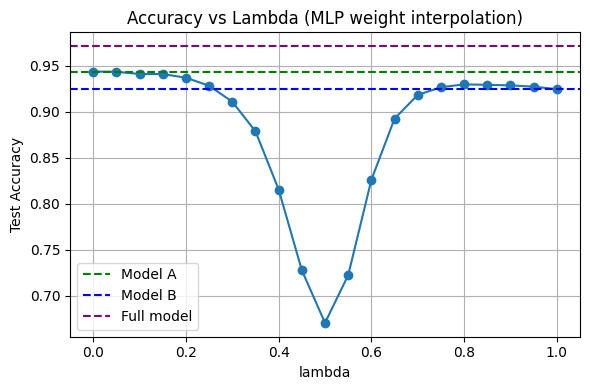

In [58]:
plt.figure(figsize=(6,4))
plt.plot(lambdas, merged_naive_acc, marker='o')
plt.axhline(evaluate_model_state_dict(stateA), color='green', linestyle='--', label="Model A")
plt.axhline(evaluate_model_state_dict(stateB), color='blue', linestyle='--', label="Model B")
plt.axhline(evaluate_model_state_dict(modelFull_state), color='purple', linestyle='--', label="Full model")
plt.title("Accuracy vs Lambda (MLP weight interpolation)")
plt.xlabel("lambda")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

In [50]:
# def evaluate_loss_state_dict(state_dict):
#     m = MLP()
#     m.load_state_dict(state_dict)
#     m.eval()
#     criterion = torch.nn.NLLLoss()

#     total_loss = 0.0
#     total_count = 0

#     with torch.no_grad():
#         for x, y in test_loader:
#             out = m(x)
#             loss = criterion(out, y)
#             total_loss += loss.item() * x.size(0)
#             total_count += x.size(0)

#     return total_loss / total_count

# lossA = evaluate_loss_state_dict(stateA)
# lossB = evaluate_loss_state_dict(stateB)
# combined_loss_AB = 0.5 * (lossA + lossB)


# lambdas = np.linspace(0, 1, 21)
# merged_naive_loss = []
# for lam in lambdas:
#     s2 = interp_states(stateA, stateB, lam)
#     merged_naive_loss.append(evaluate_loss_state_dict(s2))


# Loss_barrier_naive = max(merged_naive_loss) - combined_loss_AB


In [51]:
def compute_similarity(W_A, W_B):
    """
    Compute the neuron-to-neuron similarity matrix S,
    where S[i,j] = dot product between row i of W_A
    and row j of W_B.

    W_A: (out_features, in_features)
    W_B: (out_features, in_features)

    Returns:
        S: (out_features, out_features) similarity matrix
    """
    # Ensure numpy arrays
    A = np.asarray(W_A)
    B = np.asarray(W_B)

    # Dot product matrix: A @ B.T
    S = A @ B.T
    return S

def linear_assignment_problem(sim):
    """
    Given similarity matrix sim[i,j], find permutation P (as a matrix)
    that maximizes total similarity. Hungarian solves a MIN cost,
    so cost = -sim.
    """
    cost = -sim                       # maximize sim ⇒ minimize -sim
    row_ind, col_ind = linear_sum_assignment(cost)

    n = sim.shape[0]
    P = np.zeros((n, n), dtype=np.float32)
    P[row_ind, col_ind] = 1.0
    return P


def match_neurons(A, B, layers, num_steps=10):
    """
    A, B: dict layer_name -> weight matrix (numpy)
    layers: ordered list, e.g. ["fc1","fc2","fc3"]

    Returns:
        P : dict layer_name -> permutation matrix P[l]
    """

    # Initialize P[l] = identity
    P = {}
    for l in layers:
        n = A[l].shape[0]
        P[l] = np.eye(n, dtype=np.float32)

    for step in range(num_steps):
        progress = False

        # Random layer order
        order = layers.copy()
        np.random.shuffle(order)

        for idx, l in enumerate(order):

            W_A = A[l]
            W_B = B[l]

            # Determine previous layer permutation matrix
            if l == layers[0]:
                P_prev = np.eye(W_B.shape[1], dtype=np.float32)   # input dim identity
            else:
                prev_layer = layers[layers.index(l) - 1]
                # P_prev has to match input dimension:
                P_prev = P[prev_layer].T  # transpose = inverse for permutation matrix

            # Similarity under current permutations
            W_eff = P[l] @ W_B @ P_prev
            sim_old = compute_similarity(W_A, W_eff)
            mean_old = sim_old.mean()

            # Solve LAP to get better P[l]
            P_new = linear_assignment_problem(sim_old)
            W_eff_new = P_new @ W_B @ P_prev
            sim_new = compute_similarity(W_A, W_eff_new)
            mean_new = sim_new.mean()

            if mean_new > mean_old + 1e-12:
                P[l] = P_new
                progress = True

        if not progress:
            break

    return P



In [52]:
A = {
    "fc1": modelA.fc1.weight.detach().numpy(),
    "fc2": modelA.fc2.weight.detach().numpy(),
    "fc3": modelA.fc3.weight.detach().numpy(),
}

B = {
    "fc1": modelB.fc1.weight.detach().numpy(),
    "fc2": modelB.fc2.weight.detach().numpy(),
    "fc3": modelB.fc3.weight.detach().numpy(),
}

layers = ["fc1", "fc2", "fc3"]

P = match_neurons(A, B, layers)



In [53]:
def apply_permutations_to_B(B_state, P, layers=["fc1","fc2","fc3"],
                            next_layer={"fc1":"fc2","fc2":"fc3","fc3":"fc4"}):
    """
    Apply permutation matrices P[l] to B_state (bias-free version).

    - Permute rows of W_l using P[l]
    - Permute columns of W_{l+1} using P[l]^T
    - Does NOT modify bias terms

    Parameters
    ----------
    B_state : dict (state_dict of model B)
    P       : dict layer_name -> permutation matrix for that layer
    layers  : list of layers to match
    next_layer : dict mapping layer -> next layer

    Returns
    -------
    new_state : dict
        Permuted version of B_state
    """

    new_state = {k: v.clone() for k, v in B_state.items()}

    for l in layers:
        P_l = P[l]

        # 1. Permute ROWS of W_l  (output neurons)
        W = new_state[f"{l}.weight"].detach().cpu().numpy()
        W_new = P_l @ W
        new_state[f"{l}.weight"] = torch.from_numpy(W_new).float()

        # 2. Permute COLUMNS of W_{l+1}  (inputs to next layer)
        if l in next_layer:
            nxt = next_layer[l]
            Wn = new_state[f"{nxt}.weight"].detach().numpy()
            Wn_new = Wn @ P_l.T     # because inputs permute with Pᵀ
            new_state[f"{nxt}.weight"] = torch.from_numpy(Wn_new).float()

    return new_state


In [59]:
# 1. Run your match_neurons(A, B, layers) function
P = match_neurons(A, B, layers=["fc1","fc2","fc3"])


print(P)

# 2. Permute B’s parameters
stateB_perm = apply_permutations_to_B(modelB.state_dict(), P)

# 3. Load into a fresh model
modelB_perm = MLP()
modelB_perm.load_state_dict(stateB_perm)

{'fc1': array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(512, 512), dtype=float32), 'fc2': array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(512, 512), dtype=float32), 'fc3': array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(512, 512), dtype=float32)}


<All keys matched successfully>

In [55]:
lambdas = np.linspace(0, 1, 21)
merged_permuted_weights_acc2 = []
for lam in lambdas:
    s = interp_states(stateA, stateB_perm, lam)
    merged_permuted_weights_acc2.append(evaluate_model_state_dict(s))
print("Interpolation of permuted weights done.")

Interpolation of permuted weights done.


In [56]:
print(min(merged_naive_acc), min(merged_permuted_weights_acc2))


0.6702 0.6702


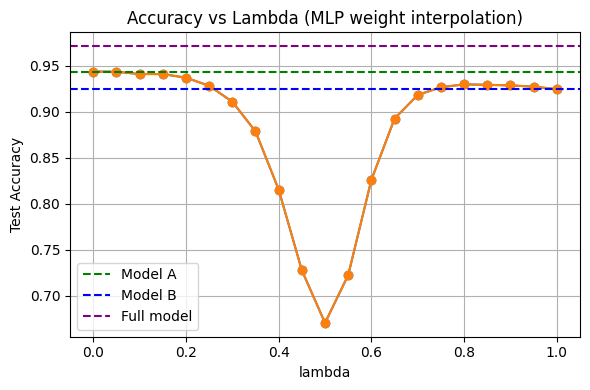

In [57]:
plt.figure(figsize=(6,4))
plt.plot(lambdas, merged_naive_acc, marker='o')
plt.plot(lambdas, merged_permuted_weights_acc2, marker='o')
plt.axhline(evaluate_model_state_dict(stateA), color='green', linestyle='--', label="Model A")
plt.axhline(evaluate_model_state_dict(stateB), color='blue', linestyle='--', label="Model B")
plt.axhline(evaluate_model_state_dict(modelFull_state), color='purple', linestyle='--', label="Full model")
plt.title("Accuracy vs Lambda (MLP weight interpolation)")
plt.xlabel("lambda")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

### Basic Permutation Algorithm

In [22]:
def compute_cost_matrix(A, B):
    # A, B: numpy arrays of shape (out_features, in_features)
    diff = A[:, None, :] - B[None, :, :]
    cost = np.sum(diff**2, axis=2)
    return cost


In [23]:
def get_weight_rows(state, layer_name):
    W = state[f"{layer_name}.weight"].cpu().numpy()   # shape (out, in)
    return W


In [24]:
def apply_perm(state, layer_name, perm):
    new_state = dict(state)

    # Permute rows of the current layer
    W = state[f"{layer_name}.weight"].cpu().numpy()
    new_state[f"{layer_name}.weight"] = torch.from_numpy(W[perm, :])

    # Permute columns of the next layer's weight matrix
    next_layer = {"fc1": "fc2", "fc2": "fc3", "fc3": "fc4"}
    if layer_name in next_layer:
        nxt = next_layer[layer_name]
        Wn = state[f"{nxt}.weight"].cpu().numpy()
        new_state[f"{nxt}.weight"] = torch.from_numpy(Wn[:, perm])

    return new_state


In [26]:
def match_layer(stateA, stateB, layer_name):
    A = get_weight_rows(stateA, layer_name)
    B = get_weight_rows(stateB, layer_name)

    cost = compute_cost_matrix(A, B)
    row_ind, col_ind = linear_sum_assignment(cost)

    # Build perm so: neuron i in A ↔ neuron perm[i] in B
    perm = np.empty_like(col_ind)
    perm[row_ind] = col_ind
    return perm


In [27]:
hidden_layers = ["fc1", "fc2", "fc3"]

stateB_perm = dict(stateB)

for layer in hidden_layers:
    print("Matching:", layer)
    perm = match_layer(stateA, stateB_perm, layer)
    stateB_perm = apply_perm(stateB_perm, layer, perm)


Matching: fc1
Matching: fc2
Matching: fc3


In [ ]:
print("Accuracy of permuted Model B:",evaluate_model_state_dict(stateB_perm))



Accuracy of permuted Model B: 0.9453


In [ ]:
lambdas = np.linspace(0, 1, 21)
merged_permuted_weights_acc = []
for lam in lambdas:
    s = interp_states(stateA, stateB_perm, lam)
    merged_permuted_weights_acc.append(evaluate_model_state_dict(s))
print("Interpolation of permuted weights done.")

Naive interpolation done.


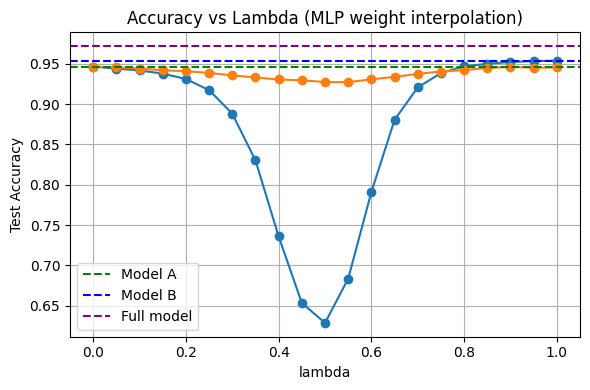

In [30]:
plt.figure(figsize=(6,4))
plt.plot(lambdas, merged_naive_acc, marker='o')
plt.plot(lambdas, merged_permuted_weights_acc, marker='o')
plt.axhline(evaluate_model_state_dict(stateA), color='green', linestyle='--', label="Model A")
plt.axhline(evaluate_model_state_dict(stateB), color='blue', linestyle='--', label="Model B")
plt.axhline(evaluate_model_state_dict(modelFull_state), color='purple', linestyle='--', label="Full model")
plt.title("Accuracy vs Lambda (MLP weight interpolation)")
plt.xlabel("lambda")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

### loss surface???

In [45]:
def flatten_state(state_dict):
    flat = []
    meta = []
    #### We are generating a flattened array of all params so we can treat final parameters as somewhat pointwise
    for k, v in state_dict.items():
        #### k is the different layer keys. i.e fc1.weight etc, v is the tensor of params weights and biases
        #### we convert from tensor to flat array
        arr = v.detach().numpy().ravel()
        flat.append(arr)
        ### store in meta to build back up after. i.e back to tensor
        meta.append((k, v.shape, arr.size))
    return np.concatenate(flat), meta

def unflatten_state(vec, meta):
    d = {}
    offset = 0
    for k, shape, size in meta:
        part = vec[offset:offset+size]
        offset += size
        d[k] = torch.from_numpy(part.reshape(shape)).float()
    return d

# ------------------------------------------------------------
# 2. Build the 2D plane directions
# ------------------------------------------------------------
stateA = modelA.state_dict()
stateB = modelB.state_dict()

flatA, metaA = flatten_state(stateA)
flatB, metaB = flatten_state(stateB)
flatB_perm,metaB_perm = flatten_state(stateB_perm)



# X-axis direction is defined by direction from permuted B to permuted A
u = flatB_perm - flatA
u /= np.linalg.norm(u)

# Y-axis direction defined by direction from permuted B to raw B
v = flatB_perm - flatB   # raw B → permuted B
v = v - np.dot(v, u) * u  # make orthogonal to u, in order to be an appopriate axis
v /= np.linalg.norm(v)


# Differences relative to A
delta_Braw  = flatB      - flatA
delta_Bperm = flatB_perm - flatA

# Coordinates in the (u, v) plane
### A is (0,0) is u,v plane 

Braw_x  = np.dot(delta_Braw,  u)
Braw_y  = np.dot(delta_Braw,  v)

Bperm_x = np.dot(delta_Bperm, u)
Bperm_y = np.dot(delta_Bperm, v)


# ------------------------------------------------------------
# 3. Evaluate the loss on a grid over (α, β)
# ------------------------------------------------------------
def evaluate_flat_vector(vec, meta):
    """Convert vec -> model -> accuracy & loss."""
    state = unflatten_state(vec, meta)
    model = MLP()
    model.load_state_dict(state)
    model.eval()

    total_loss = 0.0
    total_count = 0

    criterion = torch.nn.NLLLoss()

    with torch.no_grad():
        for x, y in test_loader:
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            total_count += x.size(0)

    return total_loss / total_count  # average loss


alpha_min = min(0, Braw_x, Bperm_x) - 5
alpha_max = max(0, Braw_x, Bperm_x) + 5

beta_min = min(0, Braw_y, Bperm_y) - 5
beta_max = max(0, Braw_y, Bperm_y) + 5


# Grid definition
G = 10
alphas = np.linspace(alpha_min, alpha_max, G)
betas  = np.linspace(beta_min, beta_max, G)


loss_surface = np.zeros((G, G))

print("Evaluating 2D loss surface...")

for i, a in enumerate(alphas):
    for j, b in enumerate(betas):
        theta = flatA + a * u + b * v     # point in 2D plane
        loss_surface[i, j] = evaluate_flat_vector(theta, metaA)
        print(f"({i},{j}) loss={loss_surface[i,j]:.4f}")

np.save("loss_surface.npy", loss_surface)
np.save("alphas.npy", alphas)
np.save("betas.npy", betas)

Evaluating 2D loss surface...
(0,0) loss=0.2997
(0,1) loss=0.3170
(0,2) loss=0.5288
(0,3) loss=0.8717
(0,4) loss=0.8986
(0,5) loss=0.5508
(0,6) loss=0.2746
(0,7) loss=0.1826
(0,8) loss=0.1787
(0,9) loss=0.2150
(1,0) loss=0.2455
(1,1) loss=0.2374
(1,2) loss=0.4048
(1,3) loss=0.8313
(1,4) loss=1.1084
(1,5) loss=0.8501
(1,6) loss=0.4287
(1,7) loss=0.2220
(1,8) loss=0.1723
(1,9) loss=0.1889
(2,0) loss=0.2161
(2,1) loss=0.1932
(2,2) loss=0.3186
(2,3) loss=0.7588
(2,4) loss=1.2520
(2,5) loss=1.1932
(2,6) loss=0.7104
(2,7) loss=0.3407
(2,8) loss=0.2034
(2,9) loss=0.1861
(3,0) loss=0.2010
(3,1) loss=0.1708
(3,2) loss=0.2677
(3,3) loss=0.6903
(3,4) loss=1.3215
(3,5) loss=1.4737
(3,6) loss=1.0419
(3,7) loss=0.5446
(3,8) loss=0.2847
(3,9) loss=0.2105
(4,0) loss=0.1944
(4,1) loss=0.1610
(4,2) loss=0.2436
(4,3) loss=0.6483
(4,4) loss=1.3391
(4,5) loss=1.6212
(4,6) loss=1.2602
(4,7) loss=0.7185
(4,8) loss=0.3755
(4,9) loss=0.2491
(5,0) loss=0.1932
(5,1) loss=0.1593
(5,2) loss=0.2399
(5,3) loss=0.640

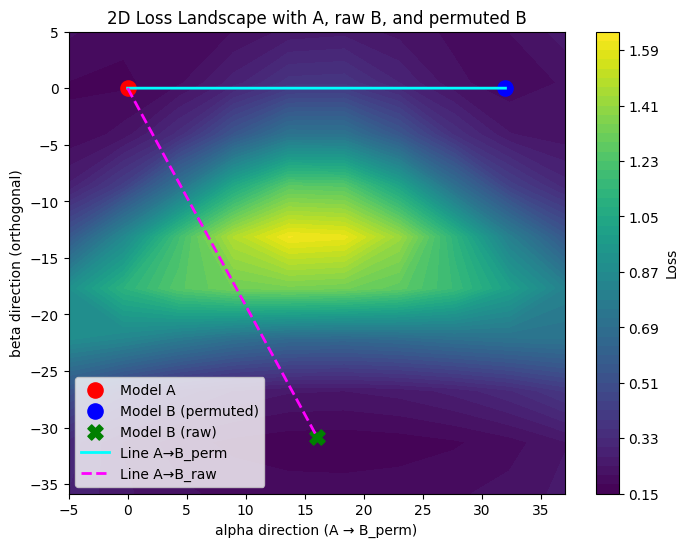

In [47]:
plt.figure(figsize=(8,6))

# Draw contour plot
CS = plt.contourf(alphas, betas, loss_surface.T, levels=50, cmap='viridis')
plt.colorbar(label="Loss")

# Plot Model A
plt.scatter(0, 0, c='red', s=120, marker='o', label='Model A')

# Plot permuted Model B (this is the aligned one)
plt.scatter(Bperm_x, Bperm_y, c='blue', s=120, marker='o', label='Model B (permuted)')

# Plot raw Model B (misaligned)
plt.scatter(Braw_x, Braw_y, c='green', s=120, marker='X', label='Model B (raw)')

# Draw line A → B_perm
plt.plot([0, Bperm_x], [0, Bperm_y],
         color='cyan', linestyle='-', linewidth=2,
         label='Line A→B_perm')

# Draw line A → B_raw
plt.plot([0, Braw_x], [0, Braw_y],
         color='magenta', linestyle='--', linewidth=2,
         label='Line A→B_raw')


plt.xlabel("alpha direction (A → B_perm)")
plt.ylabel("beta direction (orthogonal)")
plt.title("2D Loss Landscape with A, raw B, and permuted B")
plt.legend()

plt.show()



### Analysing the loss barrier

In [56]:
def evaluate_loss_state_dict(state_dict):
    m = MLP()
    m.load_state_dict(state_dict)
    m.eval()
    criterion = torch.nn.NLLLoss()

    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for x, y in test_loader:
            out = m(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            total_count += x.size(0)

    return total_loss / total_count

lossA = evaluate_loss_state_dict(stateA)
lossB = evaluate_loss_state_dict(stateB)
combined_loss_AB = 0.5 * (lossA + lossB)


lambdas = np.linspace(0, 1, 21)
merged_permuted_weights_loss = []
merged_naive_loss = []
for lam in lambdas:
    s1 = interp_states(stateA, stateB_perm, lam)
    merged_permuted_weights_loss.append(evaluate_loss_state_dict(s1))
    s2 = interp_states(stateA, stateB, lam)
    merged_naive_loss.append(evaluate_loss_state_dict(s2))


Loss_barrier_naive = max(merged_naive_loss) - combined_loss_AB
Loss_barrier_permuted = max(merged_permuted_weights_loss) - combined_loss_AB


In [57]:
print("Loss Barrier of permuted B and then merged weights:" ,Loss_barrier_permuted) 
print("Loss Barrier of nieve interpolation of weights:" ,Loss_barrier_naive)

Loss Barrier of permuted B and then merged weights: 0.24986709392070772
Loss Barrier of nieve interpolation of weights: 1.2896786876440047


In [65]:

def compute_similarity(W_A, W_B):
    """
    Compute the neuron-to-neuron similarity matrix S,
    where S[i,j] = dot product between row i of W_A
    and row j of W_B.

    W_A: (out_features, in_features)
    W_B: (out_features, in_features)

    Returns:
        S: (out_features, out_features) similarity matrix
    """
    # Ensure numpy arrays
    A = np.asarray(W_A)
    B = np.asarray(W_B)

    # Dot product matrix: A @ B.T
    S = A @ B.T
    return S

def linear_assignment_problem(sim):
    """
    Given similarity matrix sim[i,j], find permutation P (as a matrix)
    that maximizes total similarity. Hungarian solves a MIN cost,
    so cost = -sim.
    """
    cost = -sim                       # maximize sim ⇒ minimize -sim
    row_ind, col_ind = linear_sum_assignment(cost)

    n = sim.shape[0]
    P = np.zeros((n, n), dtype=np.float32)
    P[row_ind, col_ind] = 1.0
    return P


def match_neurons(A, B, layers, num_steps=10):
    """
    A, B: dict layer_name -> weight matrix (numpy)
    layers: ordered list, e.g. ["fc1","fc2","fc3"]

    Returns:
        P : dict layer_name -> permutation matrix P[l]
    """

    # Initialize P[l] = identity
    P = {}
    for l in layers:
        n = A[l].shape[0]
        P[l] = np.eye(n, dtype=np.float32)

    for step in range(num_steps):
        progress = False

        # Random layer order
        order = layers.copy()
        np.random.shuffle(order)

        for idx, l in enumerate(order):

            W_A = A[l]
            W_B = B[l]

            # Determine previous layer permutation matrix
            if l == layers[0]:
                P_prev = np.eye(W_B.shape[1], dtype=np.float32)   # input dim identity
            else:
                prev_layer = layers[layers.index(l) - 1]
                # P_prev has to match input dimension:
                P_prev = P[prev_layer].T  # transpose = inverse for permutation matrix

            # Similarity under current permutations
            W_eff = P[l] @ W_B @ P_prev
            sim_old = compute_similarity(W_A, W_eff)
            mean_old = sim_old.mean()

            # Solve LAP to get better P[l]
            P_new = linear_assignment_problem(sim_old)
            W_eff_new = P_new @ W_B @ P_prev
            sim_new = compute_similarity(W_A, W_eff_new)
            mean_new = sim_new.mean()

            if mean_new > mean_old + 1e-12:
                P[l] = P_new
                progress = True

        if not progress:
            break

    return P



In [66]:
A = {
    "fc1": modelA.fc1.weight.detach().numpy(),
    "fc2": modelA.fc2.weight.detach().numpy(),
    "fc3": modelA.fc3.weight.detach().numpy(),
}

B = {
    "fc1": modelB.fc1.weight.detach().numpy(),
    "fc2": modelB.fc2.weight.detach().numpy(),
    "fc3": modelB.fc3.weight.detach().numpy(),
}

layers = ["fc1", "fc2", "fc3"]

P = match_neurons(A, B, layers)



In [ ]:
def apply_permutations_to_B(B_state, P, layers=["fc1","fc2","fc3"],
                            next_layer={"fc1":"fc2","fc2":"fc3","fc3":"fc4"}):
    """
    Apply permutation matrices P[l] to B_state (bias-free version).

    - Permute rows of W_l using P[l]
    - Permute columns of W_{l+1} using P[l]^T
    - Does NOT modify bias terms

    Parameters
    ----------
    B_state : dict (state_dict of model B)
    P       : dict layer_name -> permutation matrix for that layer
    layers  : list of layers to match
    next_layer : dict mapping layer -> next layer

    Returns
    -------
    new_state : dict
        Permuted version of B_state
    """

    new_state = {k: v.clone() for k, v in B_state.items()}

    for l in layers:
        P_l = P[l]

        # 1. Permute ROWS of W_l  (output neurons)
        W = new_state[f"{l}.weight"].detach().cpu().numpy()
        W_new = P_l @ W
        new_state[f"{l}.weight"] = torch.from_numpy(W_new).float()

        # 2. Permute COLUMNS of W_{l+1}  (inputs to next layer)
        if l in next_layer:
            nxt = next_layer[l]
            Wn = new_state[f"{nxt}.weight"].detach().numpy()
            Wn_new = Wn @ P_l.T     # because inputs permute with Pᵀ
            new_state[f"{nxt}.weight"] = torch.from_numpy(Wn_new).float()

    return new_state


In [ ]:
# 1. Run your match_neurons(A, B, layers) function
P = match_neurons(A, B, layers=["fc1","fc2","fc3"])

# 2. Permute B’s parameters
stateB_perm = apply_permutations_to_B(modelB.state_dict(), P)

# 3. Load into a fresh model
modelB_perm = MLP()
modelB_perm.load_state_dict(stateB_perm)


<All keys matched successfully>

In [69]:
lambdas = np.linspace(0, 1, 21)
merged_permuted_weights_acc2 = []
for lam in lambdas:
    s = interp_states(stateA, stateB_perm, lam)
    merged_permuted_weights_acc2.append(evaluate_model_state_dict(s))
print("Interpolation of permuted weights done.")

Interpolation of permuted weights done.


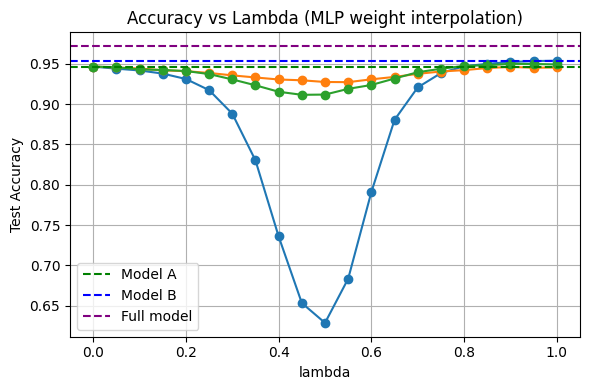

In [64]:
plt.figure(figsize=(6,4))
plt.plot(lambdas, merged_naive_acc, marker='o')
plt.plot(lambdas, merged_permuted_weights_acc, marker='o')
plt.plot(lambdas, merged_permuted_weights_acc2, marker='o')
plt.axhline(evaluate_model_state_dict(stateA), color='green', linestyle='--', label="Model A")
plt.axhline(evaluate_model_state_dict(stateB), color='blue', linestyle='--', label="Model B")
plt.axhline(evaluate_model_state_dict(modelFull_state), color='purple', linestyle='--', label="Full model")
plt.title("Accuracy vs Lambda (MLP weight interpolation)")
plt.xlabel("lambda")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()